### Preprocessing synthetic dataset

0. Print the label distribution of the real and synthetic dataset
1. See what functionality Huggingface provides?
2. Balance the dataset
3. Remove 'duplicate' entries
4. Remove 'knowledge of' or equivalent start 

In [1]:
from datasets import load_from_disk
import datasets 
from transformers import AutoTokenizer 
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
from data.CyberMetric import CyberMetric_evaluator
from openai import OpenAI 
import re
import evaluate
import numpy as np
import torch 
num_classes = 9

KAs = {"0": "miscellaneous (this includes Computer Science, Business and Law, Communication and Networking, Information Technology, Cyberspace Practice, Pedagogy, and Intelligence)",
           "1": "data security", 
           "2": "software security",
           "3": "component security", 
           "4": "connection security", 
           "5": "system security", 
           "6": "human security", 
           "7": "organizational security",
           "8": "societal security"}

/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
# load and inspect 2017 KDs 
dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
dataset = dataset.remove_columns('KSAT ID')
train_val_split = dataset.train_test_split(test_size=0.1, seed=42) 
train_dataset = train_val_split['train']
val_dataset = train_val_split['test']

In [3]:
# load synthetic dataset 
import pandas as pd
from datasets import Dataset 
input1 = pd.read_csv("data/train_synthetic_v1.csv")
input2 = pd.read_csv("data/train_synthetic_v1_labels.csv")
input1 = input2.merge(input1, on="Unnamed: 0", how='right')
dataset2 = Dataset.from_pandas(input1)
dataset2 = dataset2.remove_columns(['Unnamed: 0','label'])
print(dataset2)

input1 = pd.read_csv("data/train_synthetic_v2.csv")
input2 = pd.read_csv("data/train_synthetic_v2_labels.csv")
input1 = input2.merge(input1, on="Unnamed: 0", how='right')
dataset3 = Dataset.from_pandas(input1)
dataset3 = dataset3.remove_columns(['Unnamed: 0','label'])
print(dataset3)

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description'],
    num_rows: 1548
})
Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description'],
    num_rows: 6357
})


In [59]:
def clean_text(text): 
    special_chars = r'[\"\[\]\',]'
    cleaned_text = re.sub(special_chars, '', text)
    # replace - or _ with space 
    special_chars = r'[\_\-]'
    cleaned_text2 = re.sub(special_chars,' ', cleaned_text)
    return cleaned_text2 

def preprocess_function(example):
    text = f"{example['Statement Description']}"  # our text to be labeled is the description of the KD
    text = text[13:]                              # remove "Knowledge of" since it's the same for every KD
    text = clean_text(text)                       # remove special characters
    one_hot = list(example.values())[0:9]         # read one-hot encoding 
    example['Statement Description'] = text #tokenizer(text)                     # tokenize text 
    example['labels'] = torch.tensor(one_hot).float()
    return example 

#print(dataset[0])
#test = preprocess_function(dataset[0])
#print(test)
preprocessed = train_dataset.map(preprocess_function) 
synthetic500 = dataset2.map(preprocess_function)
synthetic2000 = dataset3.map(preprocess_function)
val_ds = val_dataset.map(preprocess_function)
print(preprocessed)

Map:   0%|          | 0/518 [00:00<?, ? examples/s]

Map:   0%|          | 0/1548 [00:00<?, ? examples/s]

Map:   0%|          | 0/6357 [00:00<?, ? examples/s]

Map:   0%|          | 0/58 [00:00<?, ? examples/s]

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'labels'],
    num_rows: 518
})


[0 1 2 3 4 5 6 7 8 9]
[15  2  3  3 11  4  0 19  3]
[0.25, 0.03333333333333333, 0.05, 0.05, 0.18333333333333332, 0.06666666666666667, 0.0, 0.31666666666666665, 0.05]


Text(0.5, 1.0, 'label distribution 2017 KDs')

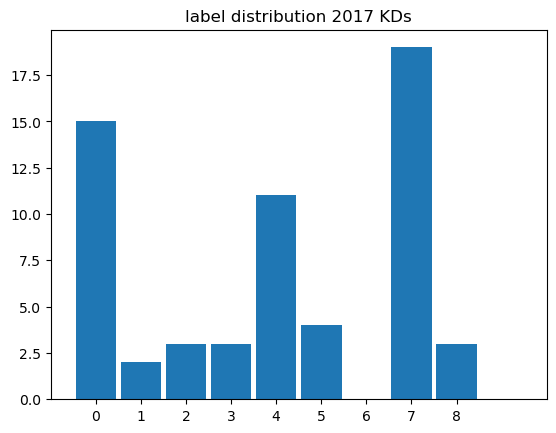

In [60]:
import matplotlib.pyplot as plt 
from collections import Counter 
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in val_ds['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
print(bins)
counts = np.bincount(non_oh)
print(counts)

# compute class weights
weights = [x / sum(counts) for x in counts]
print(weights)

# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_title('label distribution 2017 KDs')

[0 1 2 3 4 5 6 7 8 9]
[190  51  23  13  69  48   5 157  15]
[0.3327495621716287, 0.0893169877408056, 0.040280210157618214, 0.02276707530647986, 0.12084063047285463, 0.0840630472854641, 0.008756567425569177, 0.27495621716287216, 0.02626970227670753]


Text(0.5, 1.0, 'label distribution 2017 KDs')

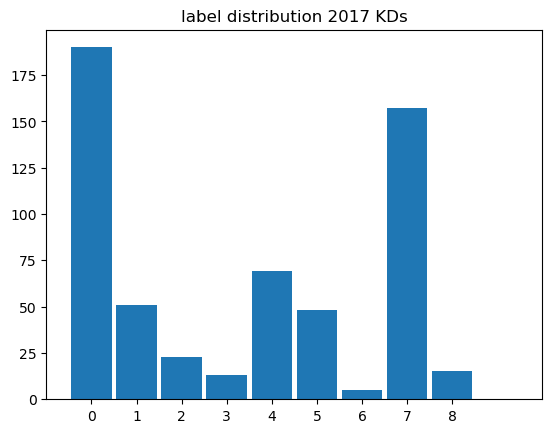

In [47]:
import matplotlib.pyplot as plt 
from collections import Counter 
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in preprocessed['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
print(bins)
counts = np.bincount(non_oh)
print(counts)

# compute class weights
weights = [x / sum(counts) for x in counts]
print(weights)

# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_title('label distribution 2017 KDs')

[0 1 2 3 4 5 6 7 8 9]
[820 804 176  69 119 515 142 305  52]


Text(0.5, 1.0, 'label distribution synthetic')

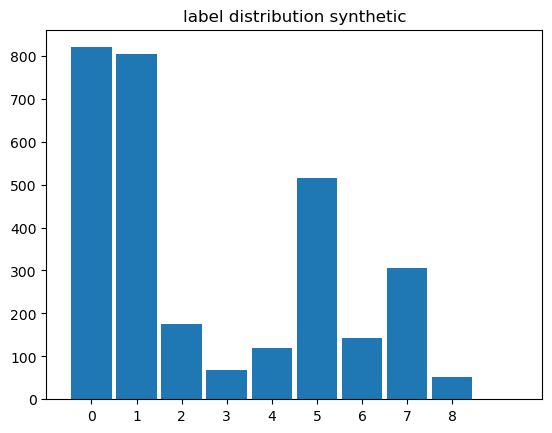

In [48]:
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in synthetic500['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
print(bins)
counts = np.bincount(non_oh)
print(counts)

fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_title('label distribution synthetic')

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description'],
    num_rows: 2066
})
[0 1 2 3 4 5 6 7 8 9]
[1010  855  199   82  188  563  147  462   67]
[0.17691613832980738, 0.20898865463521105, 0.8979160789603289, 2.1790890208915297, 0.9504537218782204, 0.31738063892203455, 1.2155462565517376, 0.3867647179937347, 2.6669447718373944]
[0.0009900990099009901, 0.0011695906432748538, 0.005025125628140704, 0.012195121951219513, 0.005319148936170213, 0.0017761989342806395, 0.006802721088435374, 0.0021645021645021645, 0.014925373134328358]


Text(0.5, 1.0, 'label distribution 2017 KDs')

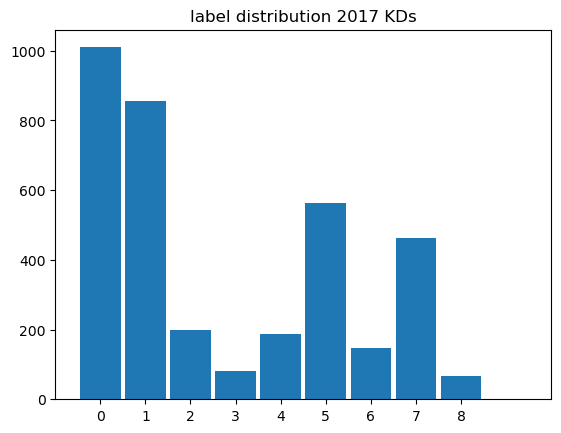

In [58]:
# merge train_dataset with synthetic dataset. 
from datasets import concatenate_datasets 
train_dataset_merged = concatenate_datasets([train_dataset, dataset2])
print(train_dataset_merged)
combi = train_dataset_merged.map(preprocess_function)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in combi['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
print(bins)
counts = np.bincount(non_oh)
print(counts)

# compute class weights = n_samples / (n_classes * n_samplesj)
weights = [1/x for x in counts]
normalized_weights = [ 9*x / sum(weights) for x in weights]
print(normalized_weights)

print(weights)

fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_title('label distribution 2017 KDs')

In [49]:
# balance the dataset more: only add the category 2, 3, 4, 6, 7 and 8 

# find indices of 

### Random forest 

In [1]:
#importing necessary packages
#https://medium.com/@mikeyo4800/how-to-build-a-multi-label-text-classification-model-using-nlp-and-machine-learning-2e05f72aad5f
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import hamming_loss
from sklearn.model_selection import train_test_split
import re

#### Compute TF-IDF features

In [3]:
# load dataset 
data = pd.read_csv("data/train_data.csv", index_col=[0])
print(data)
classes = {'0':'Miscellaneous', '1':'Data Security', '2':'Software Security', '3':'Component Security', '4':'Connection Security', 
           '5':'System Security', '6':'Human Security', '7':'Organizational Security', '8': 'Societal Security'}

#data.groupby('class').text.count().plot.bar(ylim=0)
import nltk
from nltk.stem import PorterStemmer 
from nltk.corpus import stopwords
nltk.download('stopwords')
stemmer = PorterStemmer()
words = stopwords.words("english")
data['cleaned'] = data['Statement Description'].apply(lambda x: " ".join([stemmer.stem(i) for i in re.sub("[^a-zA-Z]", " ", x).split() if i not in words]).lower())

vectorizer = TfidfVectorizer(min_df= 3, stop_words="english", sublinear_tf=True, norm='l2', ngram_range=(1, 2))
final_features = vectorizer.fit_transform(data['cleaned']).toarray()
final_features.shape

# extract labels 
labels = data.values[:,0:9]
print(labels.shape)
print(labels[:,0:9])
#one_hot = list(example.values())[1:10] 

         0  1  2  3  4  5  6  7  8  \
KSAT ID                              
K0001    0  0  0  0  1  0  0  0  0   
K0002    0  0  0  0  0  0  0  1  0   
K0003    0  0  0  0  0  0  0  0  1   
K0004    0  0  1  0  0  1  0  0  1   
K0005    1  0  0  1  1  1  0  0  0   
...     .. .. .. .. .. .. .. .. ..   
K0614    1  0  0  0  1  0  0  0  0   
K0615    0  0  0  0  0  0  1  0  0   
K0622    0  0  0  0  0  0  0  1  0   
K0624    1  0  1  0  0  0  0  0  0   
K0628    1  0  0  0  0  0  0  0  0   

                                     Statement Description  
KSAT ID                                                     
K0001    Knowledge of computer networking concepts and ...  
K0002    Knowledge of risk management processes (e.g., ...  
K0003    Knowledge of laws, regulations, policies, and ...  
K0004    Knowledge of cybersecurity and privacy principles  
K0005       Knowledge of cyber threats and vulnerabilities  
...                                                    ...  
K0614    Knowledg

[nltk_data] Downloading package stopwords to
[nltk_data]     /cephyr/users/nijdam/Alvis/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(576, 9)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]
 ...
 [0 0 0 ... 0 1 0]
 [1 0 1 ... 0 0 0]
 [1 0 0 ... 0 0 0]]


#### Train Random Forest

In [4]:
from sklearn.ensemble import RandomForestClassifier
n_estimators = 10 
rf =  RandomForestClassifier(n_estimators=n_estimators)
print(final_features.shape)
print(labels.shape)
labels = labels.astype('int') # were saved as float. 
X_train, X_test, y_train, y_test = train_test_split(final_features, labels, test_size=0.1, random_state=42)

(576, 453)
(576, 9)


In [5]:
model = rf.fit(X_train, y_train)

#### Evaluate Random Forest performance

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
output = model.predict(X_test)
print(classification_report(y_test, model.predict(X_test)))
#print(confusion_matrix(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.65      0.58      0.61        19
           1       0.00      0.00      0.00         1
           2       0.67      0.33      0.44         6
           3       0.00      0.00      0.00         2
           4       1.00      0.12      0.22         8
           5       1.00      0.14      0.25         7
           6       0.00      0.00      0.00         2
           7       0.64      0.37      0.47        19
           8       0.00      0.00      0.00         1

   micro avg       0.65      0.34      0.44        65
   macro avg       0.44      0.17      0.22        65
weighted avg       0.67      0.34      0.41        65
 samples avg       0.38      0.36      0.37        65



/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [6]:
print(classification_report(y_train, model.predict(X_train)))

NameError: name 'classification_report' is not defined

In [8]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import multilabel_confusion_matrix
mlb = MultiLabelBinarizer() 
mlb.fit_transform([(0,1),(0,1,2,3,4,5,6,7,8)])
labels2 = mlb.inverse_transform(y_test)
print(multilabel_confusion_matrix(y_test, model.predict(X_test)))
# [ TN FP ]
# [ FN TP ] 

[[[33  6]
  [ 8 11]]

 [[56  1]
  [ 1  0]]

 [[51  1]
  [ 4  2]]

 [[56  0]
  [ 2  0]]

 [[50  0]
  [ 7  1]]

 [[51  0]
  [ 6  1]]

 [[56  0]
  [ 2  0]]

 [[35  4]
  [12  7]]

 [[57  0]
  [ 1  0]]]


### Old code

In [1]:
#importing necessary packages
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns
from wordcloud import WordCloud
from nltk import FreqDist
from nltk.corpus import stopwords
#from preprocessing import TextPreprocessing #custom class


Bad key text.latex.preview in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 123 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.7.3/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 155 ('mathtext.fallback_to_cm : True  # When True, use symbols from the Computer Modern')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.7.3/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key savefig.jpeg_quality in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/ma

In [2]:
# load dataset 
data = pd.read_csv("data/train_data.csv", index_col=[0])
print(data)
classes = {'0':'Miscellaneous', '1':'Data Security', '2':'Software Security', '3':'Component Security', '4':'Connection Security', 
           '5':'System Security', '6':'Human Security', '7':'Organizational Security', '8': 'Societal Security'}

         0  1  2  3  4  5  6  7  8  \
KSAT ID                              
K0001    0  0  0  0  1  0  0  0  0   
K0002    0  0  0  0  0  0  0  1  0   
K0003    0  0  0  0  0  0  0  0  1   
K0004    0  0  1  0  0  1  0  0  1   
K0005    1  0  0  1  1  1  0  0  0   
...     .. .. .. .. .. .. .. .. ..   
K0614    1  0  0  0  1  0  0  0  0   
K0615    0  0  0  0  0  0  1  0  0   
K0622    0  0  0  0  0  0  0  1  0   
K0624    1  0  1  0  0  0  0  0  0   
K0628    1  0  0  0  0  0  0  0  0   

                                     Statement Description  
KSAT ID                                                     
K0001    Knowledge of computer networking concepts and ...  
K0002    Knowledge of risk management processes (e.g., ...  
K0003    Knowledge of laws, regulations, policies, and ...  
K0004    Knowledge of cybersecurity and privacy principles  
K0005       Knowledge of cyber threats and vulnerabilities  
...                                                    ...  
K0614    Knowledg

In [3]:
# create a dataframe for each label 

#intializing empty dct to store dataframes
genre_df = {}
for genre in range(9):
    genre = str(genre) 
    print(genre)
    #creates a key and value of only that genre
    genre_df[genre] = data[data[genre] == 1]

0
1
2
3
4
5
6
7
8


In [4]:
#text = f"{example['Statement Description']}"
# remove "Knowledge of" since it's the same for every KD
#text = text[13:]
data_sec_text = " ".join(genre_df['2']['Statement Description'])

In [5]:
print(data_sec_text[:1000])

Knowledge of cybersecurity and privacy principles Knowledge of application vulnerabilities Knowledge of cybersecurity and privacy principles and methods that apply to software development Knowledge of industry-standard and organizationally accepted analysis principles and methods Knowledge of cybersecurity and privacy principles and organizational requirements (relevant to confidentiality, integrity, availability, authentication, non-repudiation) Knowledge of programming language structures and logic Knowledge of key concepts in security management (e.g., Release Management, Patch Management) Knowledge of software debugging principles Knowledge of software design tools, methods, and techniques Knowledge of software development models (e.g., Waterfall Model, Spiral Model) Knowledge of software engineering Knowledge of system software and organizational design standards, policies, and authorized approaches (e.g., International Organization for Standardization [ISO] guidelines) relating t

In [6]:
import re

def the_cleaner(text):
        
   text_replace = text.replace('\\', '').split()
   text_strip = [re.sub(r"\([^()]*\)", "", i) for i in text_replace]

   cleaned_text = " ".join([x for x in text_strip if x.isalpha() and len(x) > 1])

   return cleaned_text

cleaned_data_sec_text = the_cleaner(data_sec_text)
print(cleaned_data_sec_text[:1000])
# this removes all examples. 

Knowledge of cybersecurity and privacy principles Knowledge of application vulnerabilities Knowledge of cybersecurity and privacy principles and methods that apply to software development Knowledge of and organizationally accepted analysis principles and methods Knowledge of cybersecurity and privacy principles and organizational requirements to Knowledge of programming language structures and logic Knowledge of key concepts in security management Release Patch Knowledge of software debugging principles Knowledge of software design and techniques Knowledge of software development models Waterfall Spiral Knowledge of software engineering Knowledge of system software and organizational design and authorized approaches International Organization for Standardization relating to system design Knowledge of interpreted and compiled computer languages Knowledge of secure coding techniques Knowledge of software related information technology security principles and methods data Knowledge of sof

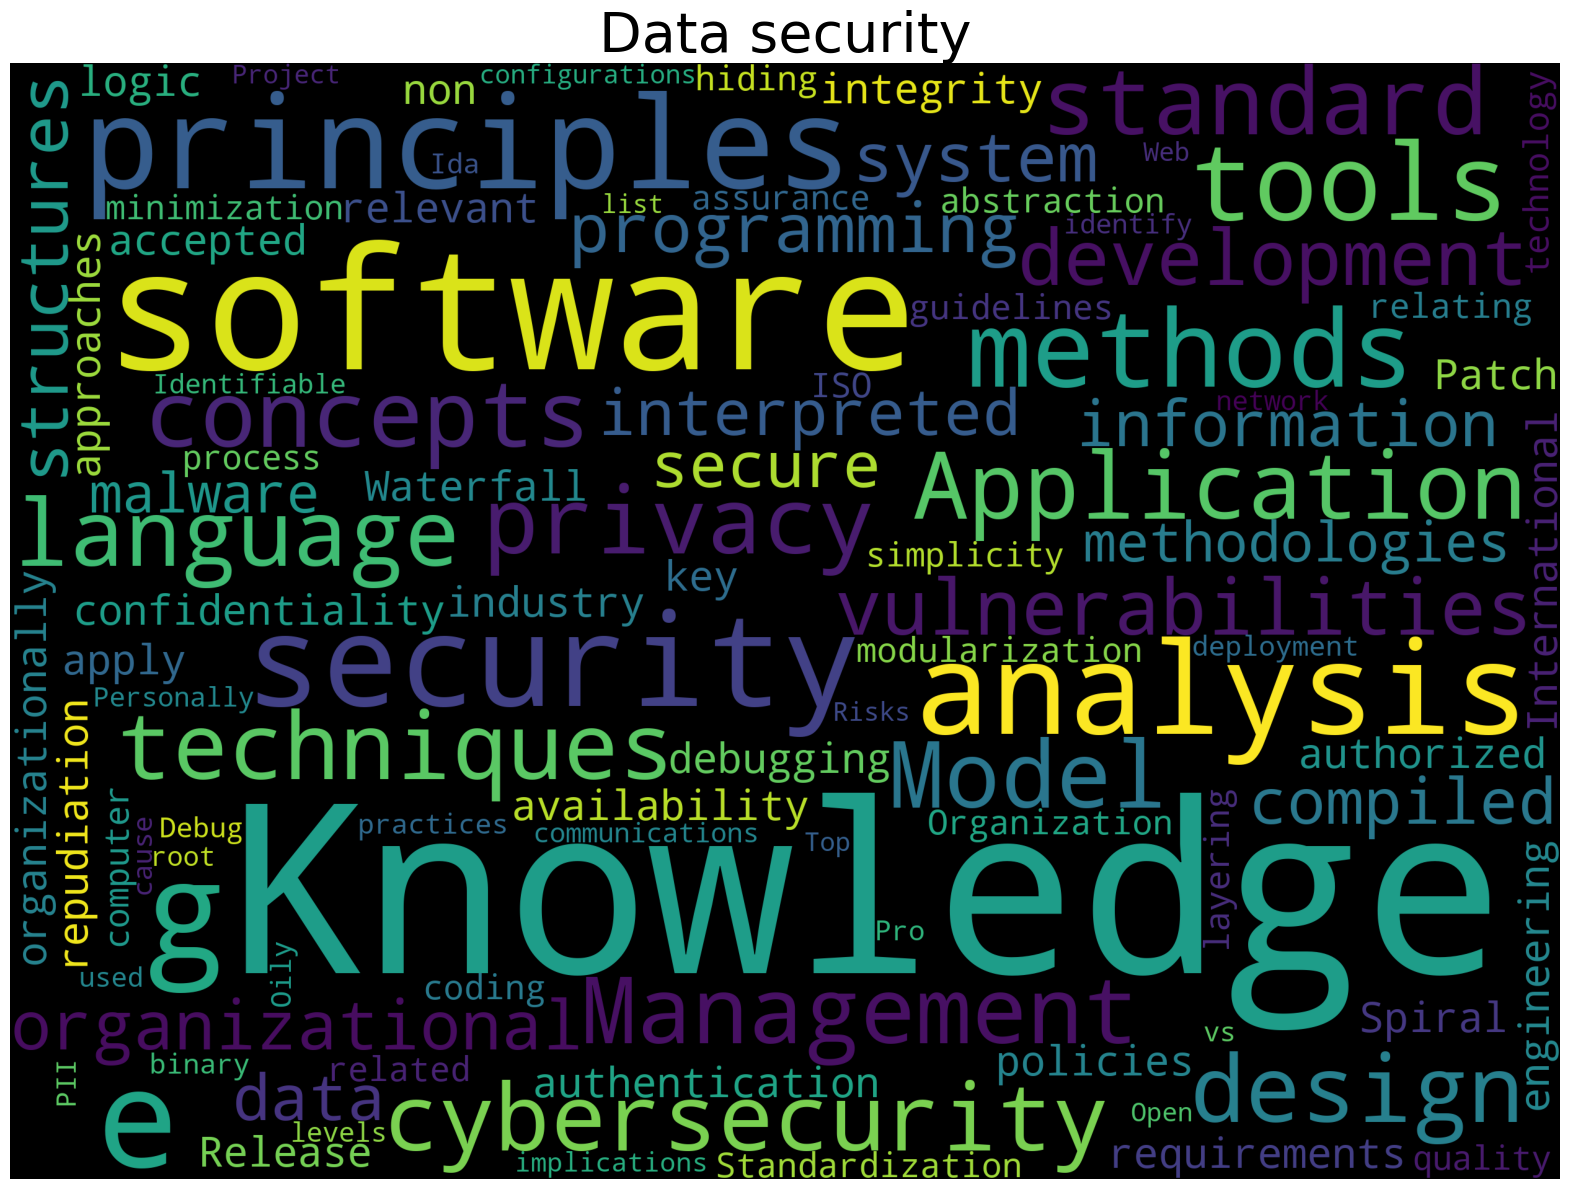

In [7]:
#setting fig size
plt.figure(figsize=(20,18))
#creating cloud
cloud = WordCloud(background_color='black',collocations=False,width=2500,height=1800).generate(data_sec_text)
plt.axis('off')
plt.title('Data security', fontsize=40)
#displaying cloud
plt.imshow(cloud)

         0  1  2  3  4  5  6  7  8  \
KSAT ID                              
K0001    0  0  0  0  1  0  0  0  0   
K0002    0  0  0  0  0  0  0  1  0   
K0003    0  0  0  0  0  0  0  0  1   
K0004    0  0  1  0  0  1  0  0  1   
K0005    1  0  0  1  1  1  0  0  0   
...     .. .. .. .. .. .. .. .. ..   
K0614    1  0  0  0  1  0  0  0  0   
K0615    0  0  0  0  0  0  1  0  0   
K0622    0  0  0  0  0  0  0  1  0   
K0624    1  0  1  0  0  0  0  0  0   
K0628    1  0  0  0  0  0  0  0  0   

                                     Statement Description  
KSAT ID                                                     
K0001    Knowledge of computer networking concepts and ...  
K0002    Knowledge of risk management processes (e.g., ...  
K0003    Knowledge of laws, regulations, policies, and ...  
K0004    Knowledge of cybersecurity and privacy principles  
K0005       Knowledge of cyber threats and vulnerabilities  
...                                                    ...  
K0614    Knowledg

In [8]:
from nltk import FreqDist

#initialize dict to store text values
genre_word_counts = {}

#looping through all target classes
for genre in range(9):
    genre = str(genre)
  
    #saving preprocess text to a variable
    genre_preprocessed_text = " ".join(genre_df[genre]['Statement Description'])
    
    #creating a freq dict
    genre_freq_dict = FreqDist(genre_preprocessed_text.split())
    
    #storing genre's freqdict in intial dictoniary for quick access
    genre_word_counts[genre] = genre_freq_dict

In [9]:
# lemmatization/normalization 
from nltk import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import itertools

def lem_process_doc(text):
    
    text = text.lower() #essential for normalization
    
    stop_words = stopwords.words('english') #basic stopwords list 
    movie_stop_words = ['b', 'fade', 'in', 'cut', 'to', 'int',   'ext', 'v', 'o', '\b', 'out', 'transition', 'to', 'angle', 'pan', 'word', 'title', 'description', 'screenplay']
    stop_words_modified = list(itertools.chain(movie_stop_words, stop_words)) #combining stop words and movie stop words
    
    wnl = WordNetLemmatizer()
    doc_norm = [tok for tok in word_tokenize(text) if ((tok.isalpha()) & (tok not in stop_words_modified))]
    
    return " ".join([wnl.lemmatize(tok) for tok in doc_norm])

In [10]:
#function to get most frequent words in freqdist
def getting_stops(freq_dist, num): 

    """
    This function takes in a frequency distrubtion and a number and returns the number of words by count.
    This function will help create an optimial stop_word list.
    
    """
    words = []
    
    for i in freq_dist.most_common(num):
        words.append(i[0])
    
    return words


#empty list to story sets of words
word_list = []

#looping for each genre
for genre in range(9):
    genre = str(genre)
  
    #appending sets of top 500 words of each genre to word_list
    word_list.append(set(getting_stops(genre_word_counts[genre], 500)))

#finding the intersection of all the sets in word_list and saving it to a variable
stops = list(set.intersection(*word_list))

In [11]:
print(stops)

['of', '(e.g.,', 'and', 'Knowledge']


(576, 453)
(576, 9)


              precision    recall  f1-score   support

           0       0.98      0.94      0.96       186
           1       0.98      0.92      0.95        52
           2       0.89      0.80      0.84        20
           3       1.00      0.64      0.78        14
           4       0.98      0.90      0.94        72
           5       1.00      0.89      0.94        45
           6       1.00      0.33      0.50         3
           7       1.00      0.90      0.95       157
           8       1.00      0.94      0.97        17

   micro avg       0.99      0.90      0.94       566
   macro avg       0.98      0.81      0.87       566
weighted avg       0.99      0.90      0.94       566
 samples avg       0.91      0.90      0.90       566



/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.65      0.58      0.61        19
           1       0.00      0.00      0.00         1
           2       1.00      0.17      0.29         6
           3       0.00      0.00      0.00         2
           4       1.00      0.25      0.40         8
           5       1.00      0.14      0.25         7
           6       0.00      0.00      0.00         2
           7       1.00      0.11      0.19        19
           8       0.00      0.00      0.00         1

   micro avg       0.74      0.26      0.39        65
   macro avg       0.52      0.14      0.19        65
weighted avg       0.80      0.26      0.34        65
 samples avg       0.29      0.28      0.29        65



/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


[[[33  6]
  [ 8 11]]

 [[57  0]
  [ 1  0]]

 [[52  0]
  [ 5  1]]

 [[56  0]
  [ 2  0]]

 [[50  0]
  [ 6  2]]

 [[51  0]
  [ 6  1]]

 [[56  0]
  [ 2  0]]

 [[39  0]
  [17  2]]

 [[57  0]
  [ 1  0]]]
